<a href="https://colab.research.google.com/github/Vihappy/Vision_Artificial/blob/main/Vision23310405.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Descargar roboflow y ultralytics
!pip install roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 135.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [2]:
#Descargar dataset con el código que nos dió roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="cC0DexqBOuW4mxhHmiGr")
project = rf.workspace("violetas-workspace-pv4ie").project("maquinas-jv7qy")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Maquinas-2 in yolov11:: 100%|██████████| 71/71 [00:00<00:00, 6227.69it/s]


In [6]:
#Cargar el modelo de YOLOV11
from ultralytics import YOLO
model = YOLO("yolo11s.pt")

In [7]:
#Entrenamiento de modelo
data_path = "/content/Maquinas-2/data.yaml"
results = model.train(data=data_path, epochs=100, imgsz=640)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Maquinas-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

In [8]:
#Cargamos el modelo mejor entrenado
custom_model = YOLO("/content/runs/detect/train/weights/best.pt")

In [9]:
#Realizamos predicciones sobre el conjunto de prueba
res = custom_model("/content/Maquinas-2/test/images")


image 1/4 /content/Maquinas-2/test/images/WhatsApp-Image-2026-03-07-at-11-03-11_jpeg.rf.567200fb95f4ce220d29ad59ec1e098d.jpg: 640x640 1 770b, 15.6ms
image 2/4 /content/Maquinas-2/test/images/WhatsApp-Image-2026-06-19-at-10-11-18_jpeg.rf.374413645b4bad074687c7ea339cf208.jpg: 640x640 1 15lx, 1 770b, 1 encl1500, 2 encl770s, 15.6ms
image 3/4 /content/Maquinas-2/test/images/WhatsApp-Image-2026-06-19-at-10-11-21_jpeg.rf.1d6cf755224b769afb09ae17a6bd1525.jpg: 640x640 3 770bs, 1 encl770, 3 floods, 15.5ms
image 4/4 /content/Maquinas-2/test/images/WhatsApp-Image-2026-06-19-at-10-11-22-1-_jpeg.rf.562cfec2205f270c9b55117c682f02f5.jpg: 640x640 1 15lx, 2 770bs, 2 encl1500s, 1 stnd770, 15.5ms
Speed: 1.8ms preprocess, 15.5ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)


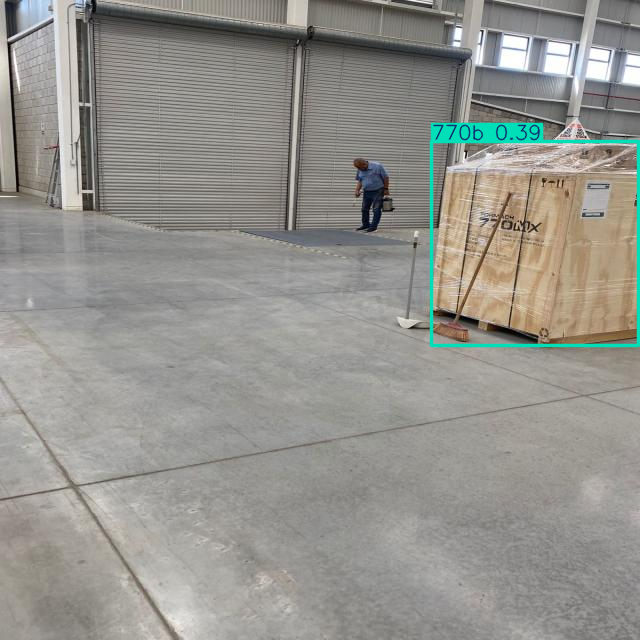

In [15]:
#Visualizamos el resultado de las imagenes
res[0].show()
